# Breast Tumor CT Segmentation — Kaggle GPU Training

Research prototype **not a clinical diagnostic system**. Trains the same
U-Net segmentation pipeline from the GitHub repo:
[https://github.com/ahmad-pervaiz/Breast-Cancer-Detection-3D-Model](https://github.com/ahmad-pervaiz/Breast-Cancer-Detection-3D-Model)

**Before running:** Settings (right panel) →
- Accelerator: **GPU T4 x2** (or P100)
- Internet: **On** (needed to `git clone` the repo)
- Add Data → attach your uploaded `breast_tumor_dataset.zip` Kaggle Dataset

See `WALKTHROUGH.md` in the repo for the full step-by-step guide.


## 1. Environment check — confirm GPU is actually attached

In [14]:
!nvidia-smi
import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "| CUDA version:", torch.version.cuda)


Wed Aug 26 11:01:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone the project code from GitHub

If you didn't push to GitHub yet, upload the `bc_tumor_detection/` folder as a
second Kaggle Dataset instead and adjust `PROJECT_DIR` below.

In [15]:
import os, subprocess

REPO_URL = "https://github.com/ahmad-pervaiz/Breast-Cancer-Detection-3D-Model.git"
CLONE_DIR = "/kaggle/working/Breast-Cancer-Detection-3D-Model"

if not os.path.exists(CLONE_DIR):
    # If repository doesn't exist locally, clone it
    subprocess.run(["git", "clone", REPO_URL, CLONE_DIR], check=True)
else:
    # If repository exists, pull the latest commits from GitHub
    subprocess.run(["git", "-C", CLONE_DIR, "pull"], check=True)

# Set working directory to repo root
os.chdir(CLONE_DIR)
print("Updated repository. Current cwd:", os.getcwd())

Already up to date.
Updated repository. Current cwd: /kaggle/working/Breast-Cancer-Detection-3D-Model


In [16]:
!ls

configs  kaggle		README.md	  runs	   src
data	 kaggle_upload	requirements.txt  scripts  WALKTHROUGH.md


## 3. Install the few dependencies Kaggle's base image doesn't already have

In [17]:
!pip install -q albumentations opencv-python-headless pyyaml
print("done")


done


In [18]:
from pathlib import Path

# Print everything inside /kaggle/input
for path in Path("/kaggle/input").rglob("*"):
    if path.is_dir():
        print(path)

/kaggle/input/datasets
/kaggle/input/datasets/ahmadpervaiz
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/valid
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/Train_masks
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/test
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/valid_masks
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/Train
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/valid/P3-Rabia-S4
/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset/valid/Tumors
/kaggle/input/datasets/ahmadpervaiz/breast-t

## 4. Locate the attached dataset

Kaggle mounts every attached Dataset under `/kaggle/input/<dataset-slug>/`.
This cell finds it automatically — it looks for the one containing a `Train/`
folder (the FINAL DATASET layout), so it works regardless of what you named
the dataset at upload time.

In [21]:
import os
from pathlib import Path

# Explicit path based on your output directory structure
DATASET_ROOT = Path("/kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset")

# Fallback auto-detection if the user mounts it elsewhere on Kaggle
if not DATASET_ROOT.exists():
    for p in Path("/kaggle/input").rglob("Train"):
        if p.is_dir():
            DATASET_ROOT = p.parent
            break

if not DATASET_ROOT or not DATASET_ROOT.exists():
    raise RuntimeError("Could not find dataset root containing 'Train' folder.")

DATASET_ROOT = str(DATASET_ROOT)
print("Using dataset_root:", DATASET_ROOT)

# List subdirectories to confirm Train, Train_masks, valid, valid_masks
!ls "{DATASET_ROOT}"

Using dataset_root: /kaggle/input/datasets/ahmadpervaiz/breast-tumor-ct-segmentation-dataset/breast_tumor_dataset
manifest.csv  test  Train  Train_masks	valid  valid_masks


## 5. Dataset audit

Same integrity checks that ran locally (corruption, mask binarity, label
consistency, patient-leakage assertion) — re-verified here since this is a
fresh environment with a fresh copy of the data.

In [22]:
!python scripts/audit_dataset.py --config configs/config.yaml --dataset_root "{DATASET_ROOT}"


Loading manifest: /kaggle/working/Breast-Cancer-Detection-3D-Model/data/manifest.csv

INTEGRITY CHECK (train + valid only - test has no ground-truth masks)
  missing_image: 0
  missing_mask: 0
  dim_mismatch: 0
  non_binary_mask: 0
  normal_nonempty_mask: 0
  tumor_empty_mask: 0
  duplicate_stem: 0

All integrity checks passed.

DATASET SUMMARY
Total images in manifest: 2152

Per split / label:
split  label 
train  Normal    514
       Tumor     858
valid  Normal    286
       Tumor     494

Total images: 2152
Positive-mask (Tumor) images: 1352
Empty-mask (Normal) images: 800

Image dimensions:
width  height
512    512       2152

Mask pixel value check: masks are binary {0, 255} per audit_report.txt (non_binary_mask count should be 0 - see integrity check output above)

Tumor pixel area statistics (positive masks only):
  min:    117 px
  max:    26973 px
  mean:   3178 px
  median: 1588 px

PATIENT-LEVEL SPLIT
TRAIN patient groups: ['Normal', 'P1-Shukran-S4', 'P2-Mumtaz-S2', 'P2-Parv

## 6. Smoke test

2 epochs on a tiny stratified subset — confirms the pipeline runs correctly
in this environment (GPU detected, data loads, checkpoints save) before
committing GPU-hours to a full run. Should take well under a minute.

In [23]:
!python scripts/train.py --config configs/config.yaml --dataset_root "{DATASET_ROOT}" --smoke_test


=== SMOKE TEST MODE: 2 epochs, small subset, separate output dir ===

Device: CUDA (Tesla T4), CUDA version: 12.8

--- Dataset integrity check (refuses to train on a broken dataset) ---
No integrity issues found.

--- Dataset summary ---
Total images in manifest: 2152

Per split / label:
split  label 
train  Normal    514
       Tumor     858
valid  Normal    286
       Tumor     494

Total images: 2152
Positive-mask (Tumor) images: 1352
Empty-mask (Normal) images: 800

Image dimensions:
width  height
512    512       2152

Mask pixel value check: masks are binary {0, 255} per audit_report.txt (non_binary_mask count should be 0 - see integrity check output above)

Tumor pixel area statistics (positive masks only):
  min:    117 px
  max:    26973 px
  mean:   3178 px
  median: 1588 px

--- Patient-level split (leakage check) ---
TRAIN patient groups: ['Normal', 'P1-Shukran-S4', 'P2-Mumtaz-S2', 'P2-Parveen-S4', 'P3-Zareena-S2', 'P5-Kousar-S4']
VALID patient groups: ['Normal', 'P1-Ruqayy

## 7. Full training

Uses every setting from `configs/config.yaml` (loss weights, augmentation,
early stopping, etc.) except `dataset_root`, which is overridden to the
Kaggle mount path. Edit `--epochs`/`--batch_size` here if you want to deviate
from the config defaults for this run.

In [9]:
!python scripts/train.py --config configs/config.yaml --dataset_root "{DATASET_ROOT}" --epochs 50 --batch_size 16


Device: CUDA (Tesla T4), CUDA version: 12.8

--- Dataset integrity check (refuses to train on a broken dataset) ---
No integrity issues found.

--- Dataset summary ---
Total images in manifest: 2152

Per split / label:
split  label 
train  Normal    514
       Tumor     858
valid  Normal    286
       Tumor     494

Total images: 2152
Positive-mask (Tumor) images: 1352
Empty-mask (Normal) images: 800

Image dimensions:
width  height
512    512       2152

Mask pixel value check: masks are binary {0, 255} per audit_report.txt (non_binary_mask count should be 0 - see integrity check output above)

Tumor pixel area statistics (positive masks only):
  min:    117 px
  max:    26973 px
  mean:   3178 px
  median: 1588 px

--- Patient-level split (leakage check) ---
TRAIN patient groups: ['Normal', 'P1-Shukran-S4', 'P2-Mumtaz-S2', 'P2-Parveen-S4', 'P3-Zareena-S2', 'P5-Kousar-S4']
VALID patient groups: ['Normal', 'P1-Ruqayya', 'P3-Rabia-S4', 'Tumors']
No named-patient overlap between train an

## 8. View training curves + a validation prediction montage inline

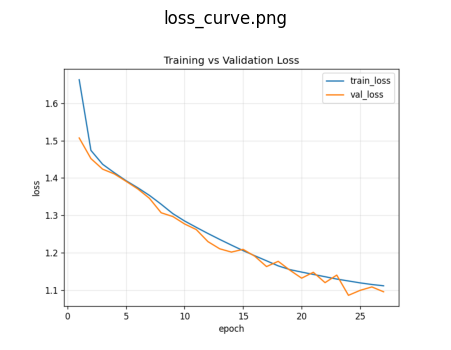

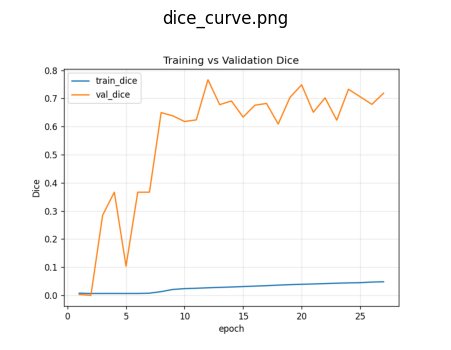

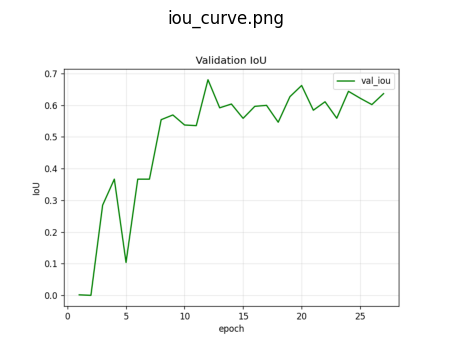

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

for name in ["loss_curve.png", "dice_curve.png", "iou_curve.png"]:
    img = Image.open(f"runs/segmentation/plots/{name}")
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis("off"); plt.title(name); plt.show()


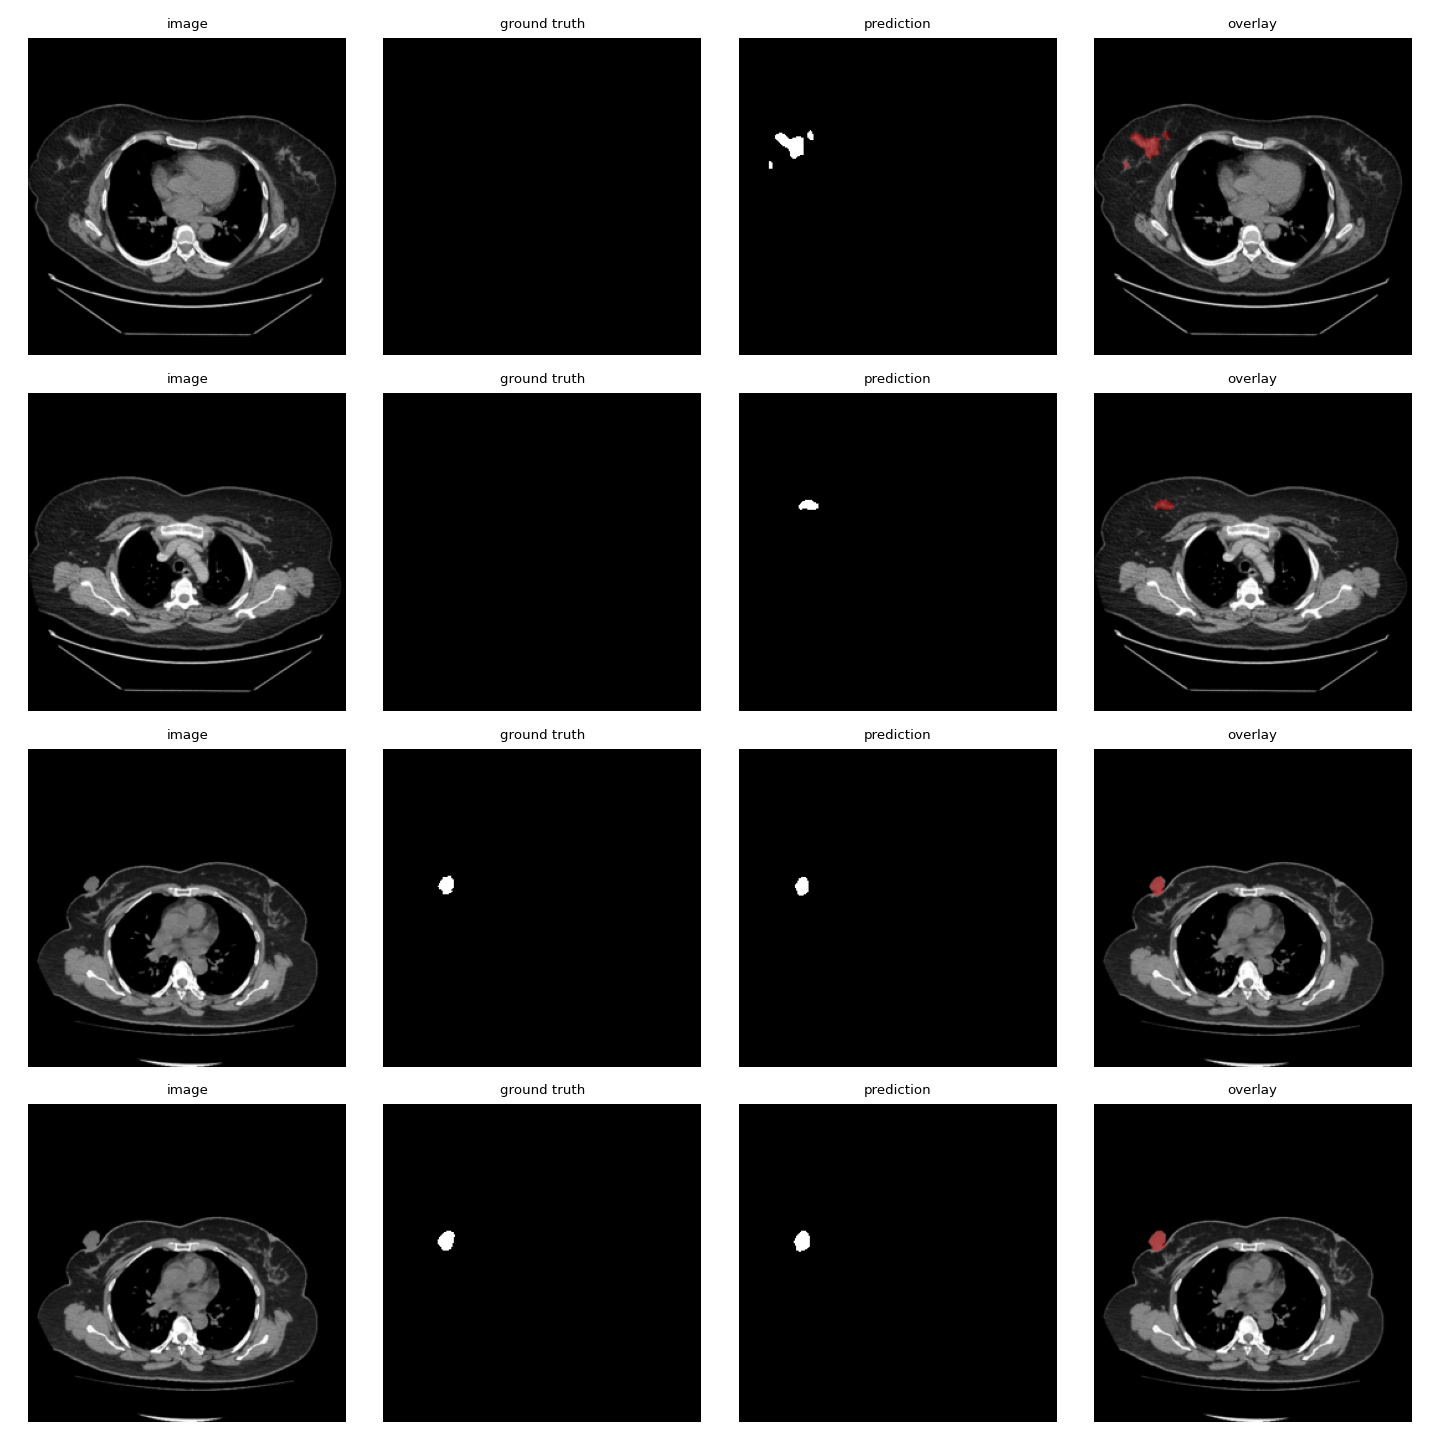

In [11]:
import glob
latest_montage = sorted(glob.glob("runs/segmentation/predictions/validation/epoch_*.png"))[-1]
Image.open(latest_montage)


## 9. Zip results for download

Kaggle auto-saves everything under `/kaggle/working/` as the notebook's
output, but a single zip of just the checkpoints/logs/plots is easier to
grab from the Output tab than digging through the repo clone.

In [12]:
import shutil
shutil.make_archive("/kaggle/working/segmentation_results", "zip", "runs/segmentation")
print("Saved: /kaggle/working/segmentation_results.zip")
print("Download it from the notebook's Output tab (top right, after committing/saving the run).")


Saved: /kaggle/working/segmentation_results.zip
Download it from the notebook's Output tab (top right, after committing/saving the run).


## 10. Next steps

1. Download `segmentation_results.zip` from the Output tab.
2. Unzip it locally into `bc_tumor_detection/runs/segmentation/` (matching
   the layout the repo expects).
3. Run inference locally (or in another Kaggle cell) with:

```
python scripts/inference.py \
    --input "FINAL DATASET/test" \
    --checkpoint runs/segmentation/checkpoints/best_model.pth \
    --output runs/segmentation/test_predictions/
```

See `WALKTHROUGH.md` for the full guide, including how to interpret the
metrics and what NOT to do with the test set.
